In [1]:
# Setup environment
import sys
import os.path
%pip install atlasopenmagic
from atlasopenmagic import install_from_environment
install_from_environment()

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Installing packages: ['aiohttp>=3.9.5', 'atlasopenmagic>=1.2.0', 'awkward>=2.6.7', 'awkward-pandas>=2023.8.0', 'coffea~=0.7.0', 'fsspec>=2025.7.0', 'hist>=2.8.0', 'ipykernel>=6.29.5', 'jupyter>=1.0.0', 'lmfit>=1.3.2', 'matplotlib>=3.9.1', 'metakernel>=0.30.2', 'notebook<7', 'numpy>=1.26.4', 'pandas>=2.2.2', 'papermill>=2.6.0', 'pip>=24.2', 'scikit-learn>=1.5.1', 'uproot>=5.3.10', 'uproot3>=3.14.4', 'fsspec-xrootd>=0.5.1', 'jupyterlab_latex~=3.1.0', 'vector>=1.4.1']
  Using cached coffea-0.7.31-py2.py3-none-any.whl.metadata (9.6 kB)
  Using cached ipykernel-6.31.0-py3-none-any.whl.metadata (4.5 kB)
INFO: pip is looking at multiple versions of coffea to determine which version is compatible with other requirements. This could take a while.
  Using cached coffea-0.7.30-py2.py3-none-any.whl.metadata (9.6 kB)
  Using cached coffea-0.7.29-py2.py3-non

In [2]:
# Import basic libraries
import copy
import os

# In case any of these imports fails, please restart the jupyter kernel and try again - it is likely the environment just needs to be updated
import requests
import uproot   # handle ROOT files
import awkward as ak    # nested, variable sized data arrays
import numpy as np
import vector   # Lorentz vectors
vector.register_awkward()
import matplotlib.pyplot as plt # plotting
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica","Arial","Nimbus Sans","DejaVu Sans"],
    "svg.fonttype": "path"
})
from tqdm import tqdm   # progress bars
import atlasopenmagic as atom   # ATLAS Open Data

In [3]:
atom.set_release("2024r-hi")

Fetching and caching all metadata for release: 2024r-hi...
Successfully cached 2 datasets.
Active release: 2024r-hi. (Datasets path: REMOTE)


In [4]:
urls = atom.get_urls("data",protocol="https",cache=True)
total_transverse_energies = ak.Array([])
for i,url in tqdm(enumerate(urls),desc="Grabbing total transverse energies...",total=len(urls)):
    with uproot.open(f"{url}:CollectionTree") as tree:
        fcal = ak.zip({
        branch.split(".")[1]: tree[branch].array() for branch in (
            f"EventInfoAuxDyn.FCalEt{x}" for x in ("A","C")
        )})
        fcal["TotalEt"] = fcal["FCalEtA"] + fcal["FCalEtC"]
        total_transverse_energies = ak.concatenate([total_transverse_energies,ak.flatten(fcal["TotalEt"],axis=None)])
    if i == 2: break

print(total_transverse_energies)

Grabbing total transverse energies...:   0%|          | 2/1913 [00:09<2:29:08,  4.68s/it]

[8.01e+05, 7.84e+05, 3.33e+06, 1.48e+06, ..., 1.12e+05, 2.53e+05, 2.45e+05]


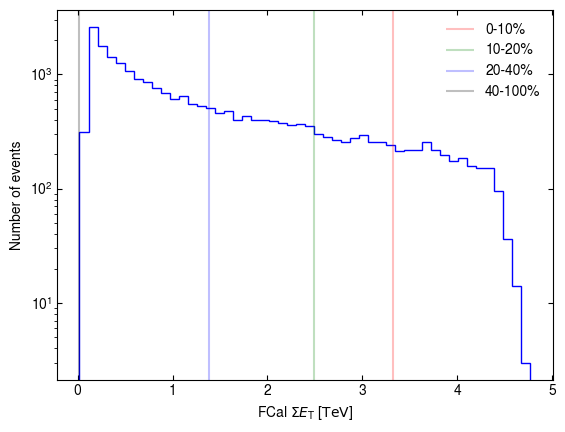

In [7]:
plt.hist(total_transverse_energies*1e-6,bins=50,histtype="step",color="blue")
plt.tick_params(axis="both",direction="in",top=True,right=True)
plt.yscale("log")
plt.xlabel(r"FCal $\Sigma E_\mathrm{T}$ [$\mathrm{TeV}$]")
plt.ylabel("Number of events")
centrality_ranges = {
    10: "0 - 10%",
    20: "10 - 20%",
    40: "20 - 40%",
    100:"40 - 100%"
}
centralities = [0,10,20,40,100]
centrality_bins = np.array([np.percentile(total_transverse_energies,100-x) for x in centralities[1:]])
ymax = plt.ylim()[1]
# plt.vlines(centrality_bins*1e-6,0,ymax,alpha=.33,color="k")
for i,colour, in zip(range(4),("red","green","blue","k")):
    plt.vlines(centrality_bins[i]*1e-6,0,ymax,color=colour,alpha=.25,label=f"{centralities[i]}-{centralities[i+1]}%")
plt.legend(frameon=False)